In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.stattools import adfuller, kpss

PROCESSED_DIR = Path("../data/processed")
df = pd.read_parquet(PROCESSED_DIR / "hourly_taxi_demand_2023.parquet")
df = df.set_index('pickup_hour').sort_index()

print(f"Loaded {len(df):,} hourly observations")
print(f"Range: {df.index.min()} to {df.index.max()}")

ts = df['trip_count']
ts.head()

Loaded 8,760 hourly observations
Range: 2023-01-01 00:00:00 to 2023-12-31 23:00:00


pickup_hour
2023-01-01 00:00:00    4809.0
2023-01-01 01:00:00    5022.0
2023-01-01 02:00:00    4387.0
2023-01-01 03:00:00    3326.0
2023-01-01 04:00:00    2131.0
Name: trip_count, dtype: float64

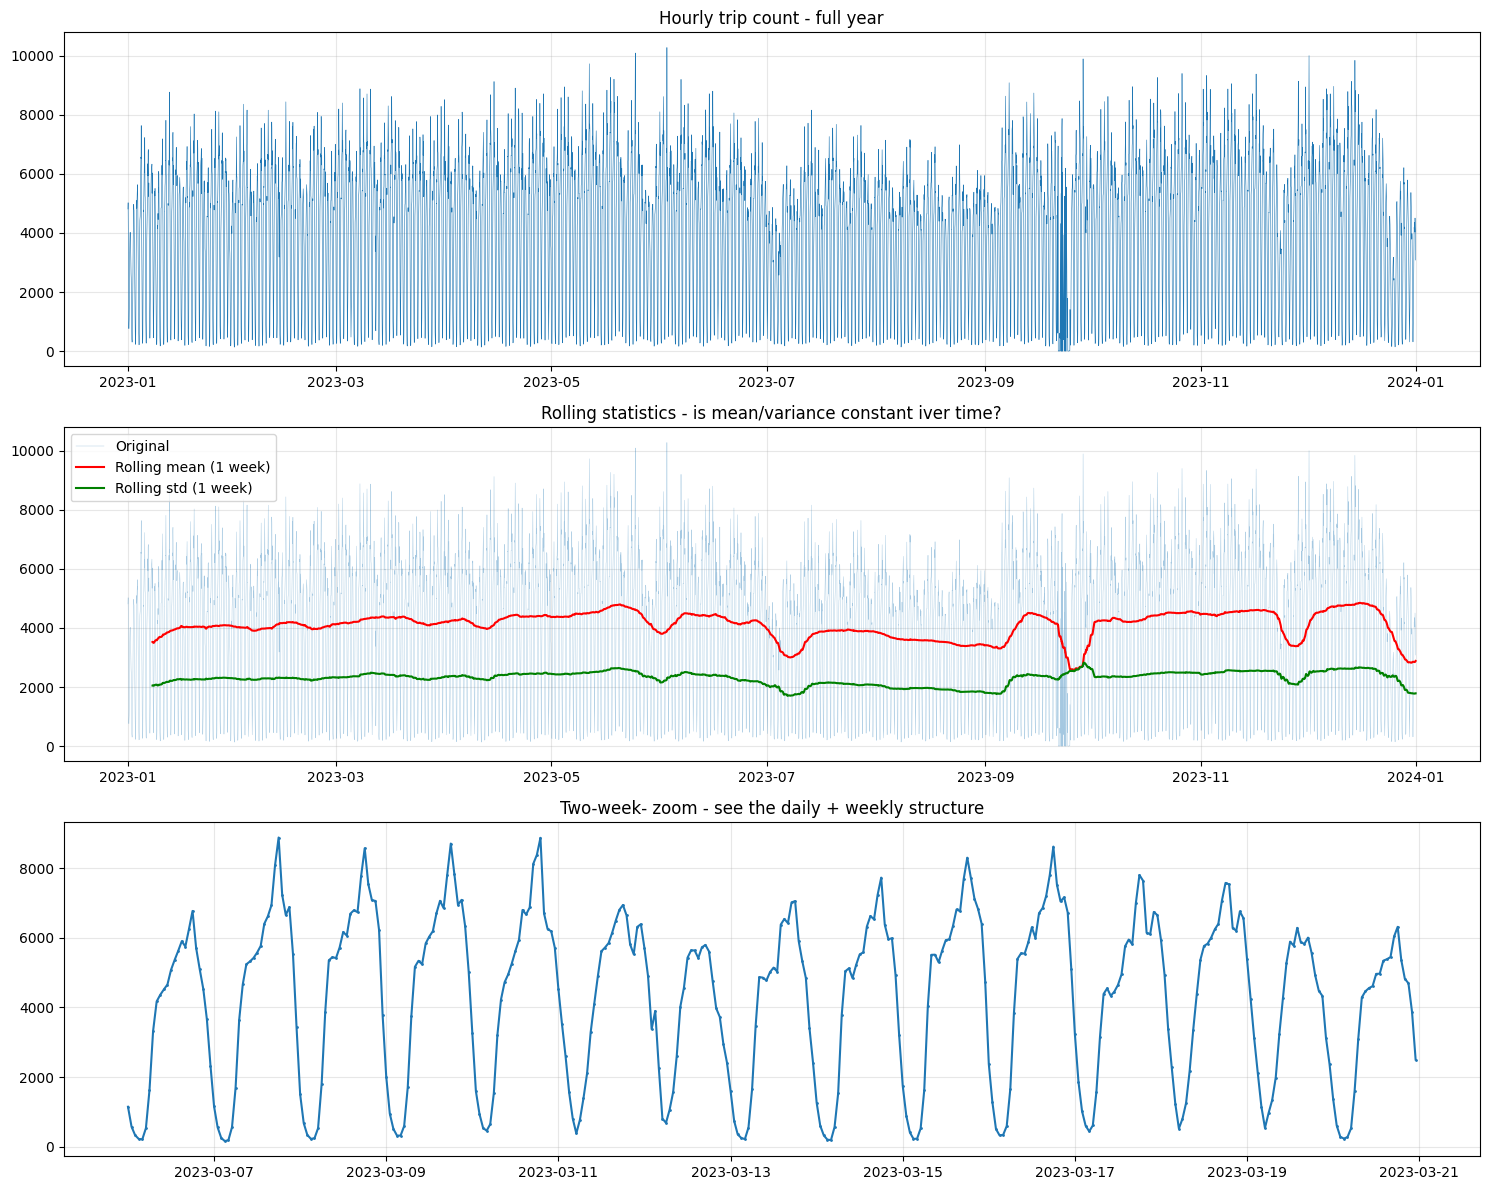

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

axes[0].plot(ts, linewidth=0.4)
axes[0].set_title('Hourly trip count - full year')
axes[0].grid(True, alpha=0.3)

rolling_mean = ts.rolling(window=24*7).mean()
rolling_std = ts.rolling(window=24*7).std()

axes[1].plot(ts, linewidth=0.3, alpha=0.4, label='Original')
axes[1].plot(rolling_mean, color='red', label='Rolling mean (1 week)')
axes[1].plot(rolling_std, color='green', label='Rolling std (1 week)')
axes[1].set_title('Rolling statistics - is mean/variance constant iver time?')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(ts['2023-03-06':'2023-03-20'], marker='.', markersize=2)
axes[2].set_title('Two-week- zoom - see the daily + weekly structure')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# kettős szezonalitás: napi (24h) + heti (168h)
# In september there are imputed values -> Ophelia hurricane

In [4]:
def stationarity_report(series: pd.Series, name: str = 'Series') -> None:
    """
    Run ADF and KPSS, print interpreted results side by side.
    """

    series = series.dropna()

    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series, autolag='AIC')

    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        kpss_stat, kpss_p, _, kpss_crit = kpss(series, regression='c', nlags='auto')

    print(f"=== Stationarity report: {name}===\n")
    print(f"ADF statistic: {adf_stat:.4f} p-value: {adf_p:.4f}")
    print(f"H0 = non-stationary (unit root)")
    print(f"-> {'REJECT HO => looks STATIONARITY' if adf_p < 0.05 else 'FAIL to reject => looks NON-STATIONARY'}\n")

    print(f"KPSS statistic: {kpss_stat:.4f} p-value: {kpss_p:.4f}")
    print(f"H0 = stationary")
    print(f"-> {'REJECT HO => looks NON-STATIONARY' if kpss_p < 0.05 else 'FAIL to reject => looks STATIONARY'}\n")

    adf_stationary = adf_p < 0.05
    kpss_stationary = kpss_p >= 0.05

    if adf_stationary and kpss_stationary:
        verdict = 'Both agree: STATIONARY'
    elif not adf_stationary and not kpss_stationary:
        verdict = 'Both agree: NON-STATIONARY (differencing likely needed)'
    elif adf_stationary and not kpss_stationary:
        verdict = 'ADF=stationary, KPSS=non-stationary => TREND-STATIONARY (detrend, not difference)'
    else:
        verdict = 'ADF=non-stationary', 'KPSS=stationary => DIFFERENCE-STATIONARY (differencing helps)'
    print(f">>> COMBINED VERDICT: {verdict}")

stationarity_report(ts, 'trip_count (raw, hourly)')

=== Stationarity report: trip_count (raw, hourly)===

ADF statistic: -7.5668 p-value: 0.0000
H0 = non-stationary (unit root)
-> REJECT HO => looks STATIONARITY

KPSS statistic: 0.3182 p-value: 0.1000
H0 = stationary
-> FAIL to reject => looks STATIONARY

>>> COMBINED VERDICT: Both agree: STATIONARY


### The ADF/KPSS test shows whether the time series is stationary in terms of trend. However, it does not reveal whether there is seasonality in it—and we know there is in our time series, specifically dual seasonality (24 hours per day + 168 hours per week); we saw this with our own eyes in the graphs and the heat map. So the correct conclusion is not that “we’re done,” but rather this: “The time series is trend-stationary; smoothing (d) is not necessary. BUT there is a strong seasonal structure in it, which must be handled by the seasonal part of the SARIMA model (P, D, Q, s), not by the non-seasonal part of the ARIMA model.”